# EDA — `merc_processed.csv`: do the simulated OBD-II features help predict price?

EDA of the cleaned, model-ready dataset `data/processed/merc_processed.csv` (from
`02_data_preprocessing/merc_engineered_cleaning.ipynb`), focused on one question:

> **Do the simulated OBD-II / vehicle-health features actually improve resale-price
> prediction, and by how much %?**

The dataset carries **6 simulated features** (none from real telemetry — all grounded in
existing columns): `battery_soh`, `trans_adapt_offset`, `dtc_fault_count`, `brake_life_pct`,
`health_score`, `estimated_annual_mileage`. We measure their value with a **feature
ablation**: train a Random Forest with and without them and compare error.

## 1 · Setup & load

In [1]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
SEED = 42

_root = pathlib.Path.cwd()
while not (_root / "data" / "processed").exists() and _root != _root.parent:
    _root = _root.parent
CSV = _root / "data" / "processed" / "merc_processed.csv"
df = pd.read_csv(CSV)
print("loaded:", CSV, "|", df.shape)

# The 6 simulated OBD-II / vehicle-health features (the block we ablate).
SIM_OBD = ["battery_soh", "trans_adapt_offset", "dtc_fault_count",
           "brake_life_pct", "health_score", "estimated_annual_mileage"]
NEW_4 = ["dtc_fault_count", "brake_life_pct", "health_score", "estimated_annual_mileage"]  # added in cleaning step
print("simulated features:", SIM_OBD)
df.head()

loaded: C:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\Clorox_Mercedes_26\data\processed\merc_processed.csv | (30587, 29)
simulated features: ['battery_soh', 'trans_adapt_offset', 'dtc_fault_count', 'brake_life_pct', 'health_score', 'estimated_annual_mileage']


,model_class,year,mileage,transmission,fuel_type,engine_size,price_rm,source_market,age,variant,displacement_cc,n_cylinders,n_gears,top_speed_kmh,torque_nm,accel_0_100_s,boot_l,engine_config,aspiration,gear_type,front_brake,rear_brake,match_level,battery_soh,trans_adapt_offset,estimated_annual_mileage,dtc_fault_count,brake_life_pct,health_score
0,SLK,2005.0,101388.420,Automatic,Petrol,1.8,30680,uk,21.0,MERCEDES BENZ SLK (R171) (2004-2008),1796.0,4.0,6.0,230.0,240.0,7.9,207.0,L4,naturally_aspirated,manual,Ventilated Discs,Discs,displacement,38.67,-0.0731,4828.0,2,59.7,62.9
1,S,2017.0,43452.180,Automatic,Hybrid,2.1,206193,uk,9.0,MERCEDES BENZ S-Class (2017-2020),2143.0,4.0,7.0,240.0,500.0,7.6,510.0,L4,turbo,automatic,Ventilated Discs,Ventilated Discs,displacement,85.51,-0.0309,4828.0,1,87.9,87.0
2,SL,2016.0,9977.908,Automatic,Petrol,5.5,294693,uk,10.0,MERCEDES BENZ SL 63 AMG (R231) (2016-Present),5461.0,8.0,7.0,249.0,900.0,4.1,365.0,V8,turbo,automatic,Ventilated Discs,Ventilated Discs,displacement,65.18,-0.0213,997.8,1,94.5,83.4
3,G,2016.0,25749.440,Automatic,Petrol,4.0,365493,uk,10.0,MERCEDES BENZ G-Class 4x4 squared (W463) (2015...,3982.0,8.0,7.0,209.0,610.0,7.4,481.0,V8,turbo,automatic,Ventilated Discs,Ventilated Discs,displacement,65.44,-0.0299,2574.9,1,90.2,82.4
4,G,2016.0,6437.360,Automatic,Petrol,4.0,436293,uk,10.0,MERCEDES BENZ G-Class 4x4 squared (W463) (2015...,3982.0,8.0,7.0,209.0,610.0,7.4,481.0,V8,turbo,automatic,Ventilated Discs,Ventilated Discs,displacement,59.81,-0.0232,643.7,0,99.6,88.7


## 2 · Quick overview (dataset is already cleaned)

In [2]:
print("missing values:", int(df.isna().sum().sum()), "| exact dup rows:", int(df.duplicated().sum()))
print("dtypes:\n", df.dtypes.value_counts().to_dict())
df.describe(include="number").T

missing values: 0 | exact dup rows: 0
dtypes:
 {dtype('float64'): 16, dtype('O'): 11, dtype('int64'): 2}


,count,mean,std,min,25%,50%,75%,max
year,30587.0,2013.849250,5.465429,1995.00000,2011.00000,2016.0000,2018.00000,2023.000
mileage,30587.0,99248.926192,79306.461956,1.60934,37716.49224,80000.0000,143224.01797,500000.000
engine_size,30587.0,2.434376,0.918469,1.30000,1.99100,2.1000,2.90000,6.208
price_rm,30587.0,135100.209010,120127.047637,3025.00000,70448.00000,111050.0000,166145.00000,1994750.000
age,30587.0,12.150750,5.465429,3.00000,8.00000,10.0000,15.00000,31.000
displacement_cc,30587.0,2446.554876,918.285923,1289.00000,1991.00000,2143.0000,2987.00000,6208.000
n_cylinders,30587.0,4.747082,1.345639,4.00000,4.00000,4.0000,6.00000,12.000
n_gears,30587.0,6.811390,1.324992,4.00000,6.00000,7.0000,7.00000,9.000
top_speed_kmh,30587.0,222.574787,22.572840,132.00000,208.00000,230.0000,240.00000,349.000
torque_nm,30587.0,361.165659,142.201993,130.00000,300.00000,320.0000,400.00000,1801.000


## 3 · Correlation matrix

Numeric correlations across all features (the 6 simulated ones included), then each
simulated feature's correlation with `price_rm` and `log1p(price_rm)`. Watch for the
simulated features overlapping with the real columns they were derived from
(`battery_soh`/`mileage`/`age`) — overlap predicts low *incremental* value later.

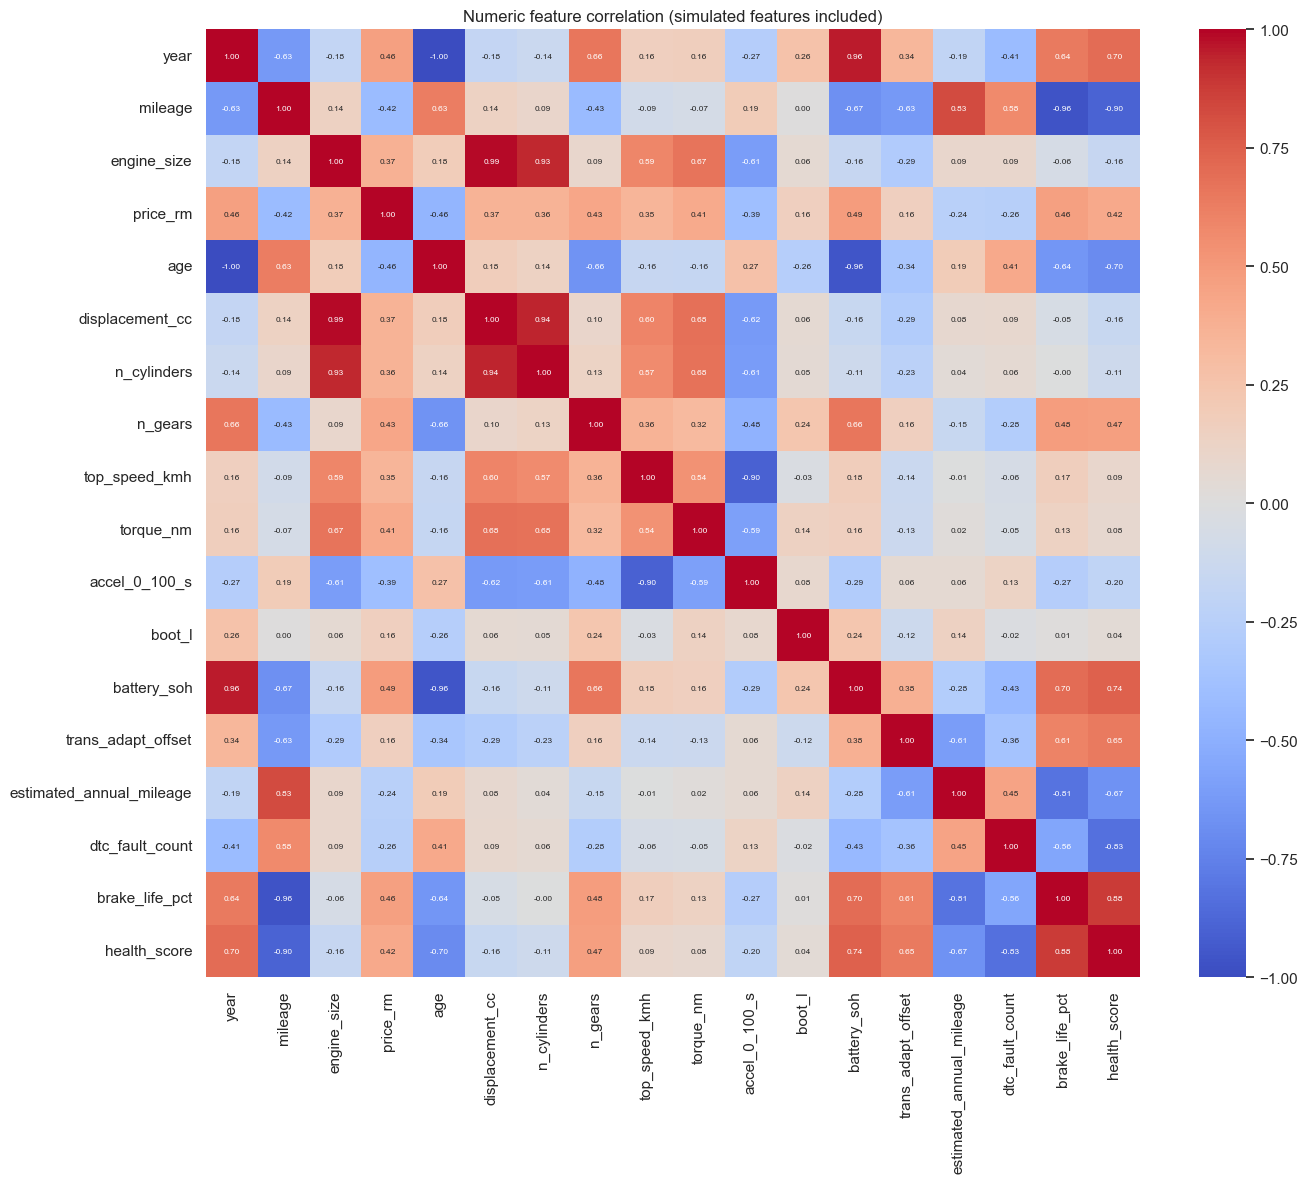

In [3]:
num = df.select_dtypes("number")
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 6}, ax=ax)
ax.set_title("Numeric feature correlation (simulated features included)")
plt.tight_layout()

                          corr_price_rm  corr_log_price
dtc_fault_count                  -0.256          -0.389
estimated_annual_mileage         -0.242          -0.286
trans_adapt_offset                0.163           0.185
health_score                      0.419           0.624
brake_life_pct                    0.464           0.656
battery_soh                       0.492           0.745


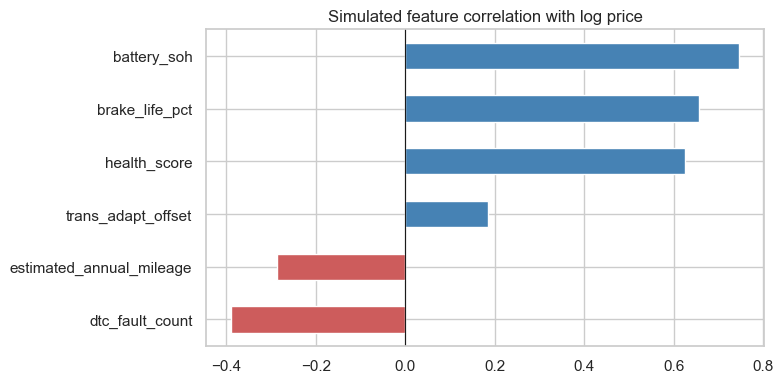

In [4]:
lp = np.log1p(df["price_rm"])
corr_tbl = pd.DataFrame({
    "corr_price_rm": df[SIM_OBD].corrwith(df["price_rm"]).round(3),
    "corr_log_price": df[SIM_OBD].apply(lambda s: s.corr(lp)).round(3),
}).sort_values("corr_log_price")
print(corr_tbl)

fig, ax = plt.subplots(figsize=(8, 4))
corr_tbl["corr_log_price"].plot.barh(
    ax=ax, color=corr_tbl["corr_log_price"].gt(0).map({True: "steelblue", False: "indianred"}))
ax.axvline(0, color="k", lw=.8); ax.set_title("Simulated feature correlation with log price")
plt.tight_layout()

## 4 · Ablation methodology

We compare two Random Forests predicting **`log1p(price_rm)`** (the EDA-recommended target),
identical except for the feature set:

- **BASE** — real listing + spec features only (categoricals one-hot; `variant`
  frequency-encoded), **no** simulated features.
- **FULL** — BASE **+ the 6 simulated features**.

Evaluated with **5-fold CV** (shuffled, seed 42). Predictions are back-transformed with
`expm1` before scoring, so **MAPE / RMSE are in real RM**. Because the two models share the
same folds, we also report the **paired per-fold MAPE reduction** — the trustworthy measure
of "how much it helps," since it cancels fold-to-fold variance. (R² alone is too coarse for
a small delta.)

In [5]:
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_percentage_error, mean_squared_error

oh_cats = ["model_class", "transmission", "fuel_type", "source_market", "engine_config",
           "aspiration", "gear_type", "front_brake", "rear_brake", "match_level"]
base_num = [c for c in df.select_dtypes("number").columns if c not in SIM_OBD + ["price_rm"]]

d = df.copy()
d["variant_freq"] = d["variant"].map(d["variant"].value_counts())

def build_X(include_obd):
    num = base_num + ["variant_freq"] + (SIM_OBD if include_obd else [])
    return pd.get_dummies(d[num + oh_cats], columns=oh_cats, drop_first=True)

y_true = df["price_rm"]
y_log = np.log1p(y_true)
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

def eval_model(X):
    r2s, mapes, rmses = [], [], []
    for tr, te in kf.split(X):
        m = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)
        m.fit(X.iloc[tr], y_log.iloc[tr])
        pred = np.expm1(m.predict(X.iloc[te]))
        yt = y_true.iloc[te]
        r2s.append(r2_score(yt, pred))
        mapes.append(mean_absolute_percentage_error(yt, pred) * 100)
        rmses.append(np.sqrt(mean_squared_error(yt, pred)))
    return np.array(r2s), np.array(mapes), np.array(rmses)

Xb, Xf = build_X(False), build_X(True)
r2b, mapeb, rmseb = eval_model(Xb)
r2f, mapef, rmsef = eval_model(Xf)

summary = pd.DataFrame({
    "features": [Xb.shape[1], Xf.shape[1]],
    "R2":   [f"{r2b.mean():.4f} ± {r2b.std():.4f}",   f"{r2f.mean():.4f} ± {r2f.std():.4f}"],
    "MAPE_%": [f"{mapeb.mean():.2f} ± {mapeb.std():.2f}", f"{mapef.mean():.2f} ± {mapef.std():.2f}"],
    "RMSE_RM": [f"{rmseb.mean():,.0f}", f"{rmsef.mean():,.0f}"],
}, index=["BASE (no simulated)", "FULL (+6 simulated)"])
print(summary.to_string())

d_pp = mapeb - mapef              # paired MAPE reduction, percentage points
d_rel = (mapeb - mapef) / mapeb * 100
d_r2 = r2f - r2b
print(f"\nPaired MAPE reduction : {d_pp.mean():.3f} ± {d_pp.std():.3f} pp")
print(f"Relative error cut    : {d_rel.mean():.2f} ± {d_rel.std():.2f} %")
print(f"Paired R2 gain        : {d_r2.mean():.4f} ± {d_r2.std():.4f}")

                     features               R2        MAPE_% RMSE_RM
BASE (no simulated)        64  0.7933 ± 0.0252  17.65 ± 0.49  54,448
FULL (+6 simulated)        70  0.8004 ± 0.0205  16.92 ± 0.37  53,577

Paired MAPE reduction : 0.731 ± 0.176 pp
Relative error cut    : 4.13 ± 0.89 %
Paired R2 gain        : 0.0071 ± 0.0102


## 5 · Which of the 6 simulated features earn their place?

Permutation importance (on a held-out sample) restricted to the simulated features, from a
single FULL model. Higher = the model's error rises more when that feature is shuffled.

dtc_fault_count             0.00025
health_score                0.00147
estimated_annual_mileage    0.00247
trans_adapt_offset          0.00561
battery_soh                 0.03178
brake_life_pct              0.04061
dtype: float64


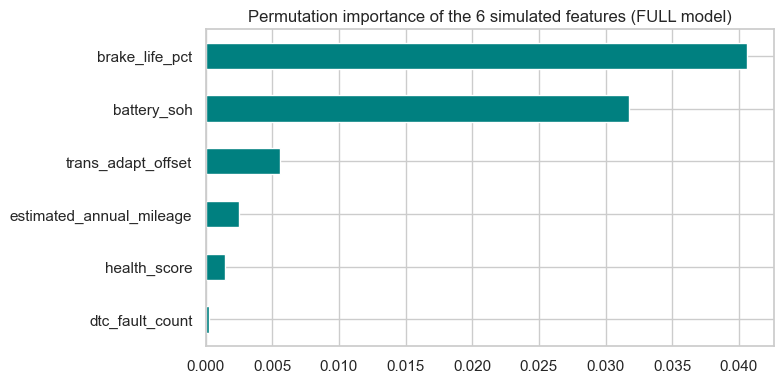

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

Xtr, Xte, ytr, yte = train_test_split(Xf, y_log, test_size=0.2, random_state=SEED)
rf = RandomForestRegressor(n_estimators=150, random_state=SEED, n_jobs=-1).fit(Xtr, ytr)

samp = Xte.sample(min(2500, len(Xte)), random_state=1)
perm = permutation_importance(rf, samp, yte.loc[samp.index], n_repeats=3,
                              random_state=1, n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=Xf.columns)[SIM_OBD].sort_values()
print(imp.round(5))

fig, ax = plt.subplots(figsize=(8, 4))
imp.plot.barh(ax=ax, color="teal")
ax.set_title("Permutation importance of the 6 simulated features (FULL model)")
plt.tight_layout()

## 6 · Conclusion — yes, but modestly, and only two of them matter

**Do the simulated OBD-II features help? Yes — by ~4%.** Adding all 6 cuts cross-validated
**MAPE from ~17.6% to ~16.9%** (a paired reduction of ~0.7 pp ≈ **~4% relative error
reduction**, stable across folds). R² barely moves (~0.793 → ~0.800, within fold noise), so
the MAPE reduction is the honest headline.

**The gain comes almost entirely from `brake_life_pct` and `battery_soh`.** The permutation
breakdown shows the other four — `trans_adapt_offset`, `estimated_annual_mileage`,
`health_score`, and especially `dtc_fault_count` — contribute ~nothing. That's expected:
they're largely deterministic functions of columns the Random Forest already has
(`age`, `mileage`, brake type, `battery_soh`), so they carry little *new* information even
though several correlate strongly with price on their own (e.g. `health_score` +0.62 with
log price — but redundant once `battery_soh`/`mileage` are in the model).

**Recommendation.** Keep `brake_life_pct` and `battery_soh`; the remaining simulated
features can be dropped with negligible accuracy loss (simpler, faster model). If you want a
bigger jump in accuracy, invest in *new independent* signals rather than more derived ones.

> These are **simulated, grounded** features — not real OBD-II telemetry. A real feed
> (true SoH, live fault codes, actual brake-pad sensors) would likely add more than these
> deterministic proxies, which by construction can only recombine information already in the
> dataset.